### 用户复购预测模型（随机森林）

In [2]:
#1.导入相应库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# 解决中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#读取数据
df =pd.read_csv('../data/clean_data.csv', parse_dates=['order_purchase_timestamp'])

In [3]:
#构建RFM特征
max_date = df['order_purchase_timestamp'].max()

In [4]:
#分组聚合计算RFM
user_rfm = df.groupby('customer_unique_id').agg(
    R=('order_purchase_timestamp', lambda x: (max_date - x.max()).days),
    F=('order_id', 'nunique'),
    M=('price', 'sum'),
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max')
).reset_index()

In [5]:
#构建目标变量：是否复购（F>1 即为复购用户，标签1；否则0）
user_rfm['is_repurchase'] = (user_rfm['F'] > 1).astype(int)

In [6]:
#计算用户生命周期长度（最后一次购买 - 第一次购买的总天数）
user_rfm['lifetime_days'] = (user_rfm['last_order'] - user_rfm['first_order']).dt.days
#计算平均客单价
user_rfm['avg_order_value'] = user_rfm['M'] / user_rfm['F']
#计算购买间隔（生命周期/购买次数）
user_rfm['purchase_interval'] = user_rfm['lifetime_days'] / user_rfm['F']
#填充无穷值（F=1时，间隔为0）
user_rfm['purchase_interval'] = user_rfm['purchase_interval'].replace([np.inf, -np.inf], 0)

In [7]:
#------------特征选择与数据集划分------------
features = ['R', 'F', 'M', 'lifetime_days', 'avg_order_value', 'purchase_interval']
X = user_rfm[features]
y = user_rfm['is_repurchase']

#划分训练和测试集（8：2）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
#-----------训练随机森林模型---------------
#初始化模型
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
#训练模型
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
#-------------模型评估--------------------
#预测
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

In [10]:
#分类报告
print("="*50)
print("模型分类报告：")
print(classification_report(y_test, y_pred))
print("="*50)

模型分类报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18501
           1       1.00      1.00      1.00       583

    accuracy                           1.00     19084
   macro avg       1.00      1.00      1.00     19084
weighted avg       1.00      1.00      1.00     19084



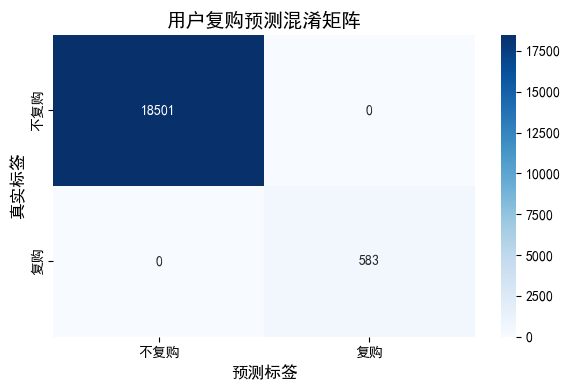

In [11]:
#混洗矩阵热力图
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['不复购', '复购'], yticklabels=['不复购', '复购'])
plt.title('用户复购预测混淆矩阵', fontsize=14)
plt.xlabel('预测标签', fontsize=12)
plt.ylabel('真实标签', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/repurchase_confusion_matrix.png', dpi=300)
plt.show()

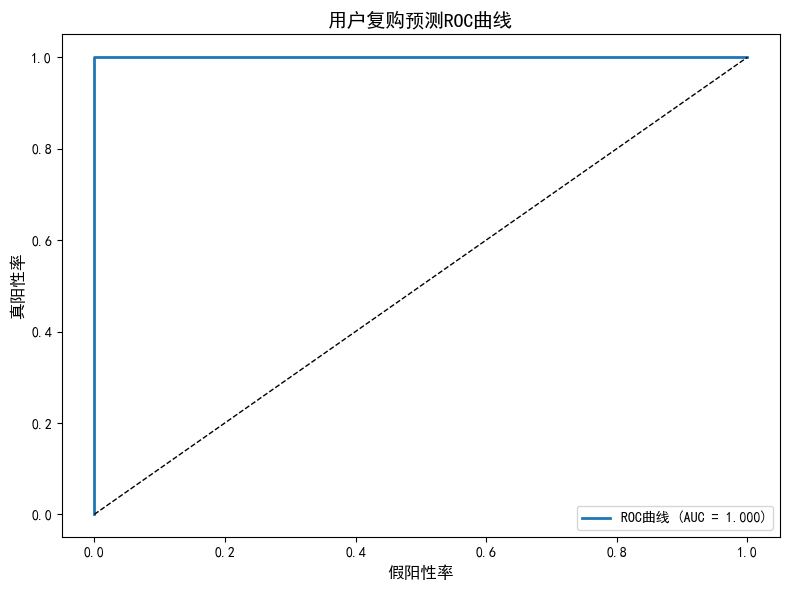

In [12]:
#ROC曲线与AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC曲线 (AUC = {auc_score:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('用户复购预测ROC曲线', fontsize=14)
plt.xlabel('假阳性率', fontsize=12)
plt.ylabel('真阳性率', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/repurchase_roc_curve.png', dpi=300)
plt.show()

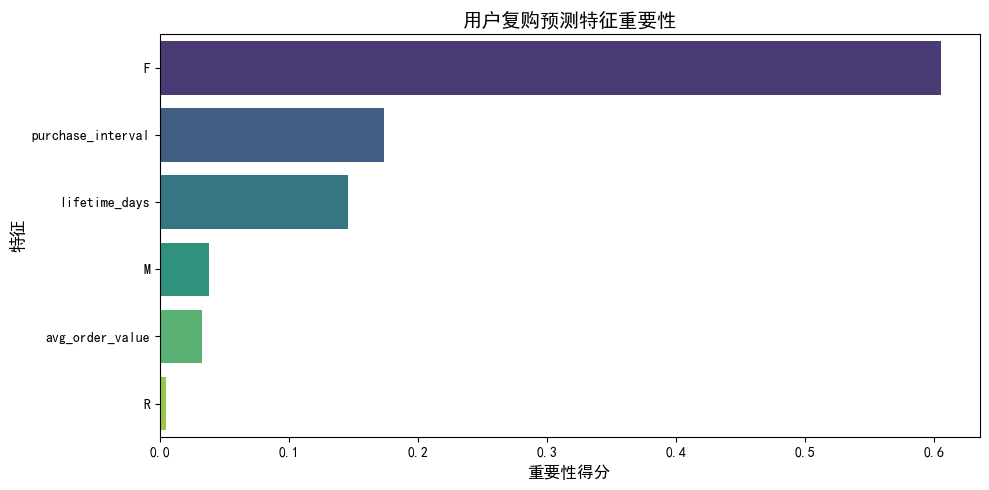

In [14]:
#特征重要性
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=feature_importance,
            hue='feature', palette='viridis', legend=False)
plt.title('用户复购预测特征重要性', fontsize=14)
plt.xlabel('重要性得分', fontsize=12)
plt.ylabel('特征', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/repurchase_feature_importance.png', dpi=300)
plt.show()

In [15]:
#------------生成运营名单---------
#给全量用户预测复购概率
user_rfm['repurchase_prob'] = rf_model.predict_proba(scaler.transform(user_rfm[features]))[:, 1]
#筛选高复购概率（>50%）和低复购概率（<20%）的用户，保留关键字段用于运营（如发送优惠券、唤醒策略)
high_prob_users = user_rfm[user_rfm['repurchase_prob'] > 0.5][['customer_unique_id', 'repurchase_prob', 'R', 'F', 'M']]
low_prob_users = user_rfm[user_rfm['repurchase_prob'] < 0.2][['customer_unique_id', 'repurchase_prob', 'R', 'F', 'M']]

high_prob_users.to_csv('../data/high_repurchase_prob_users.csv', index=False, encoding='utf-8-sig')
low_prob_users.to_csv('../data/low_repurchase_prob_users.csv', index=False, encoding='utf-8-sig')